# Inter-Annotator Agreement

Computes raw agreement, Cohen's κ, and Krippendorff's α between annotators on the manual classification labels.

In [1]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score, confusion_matrix, ConfusionMatrixDisplay
import krippendorff
import matplotlib.pyplot as plt

In [2]:
LEEN_PATH = "../../../data/annotator_agreement/manual_labels_v1_leen.csv"
V6_PATH   = "../../../data/annotator_agreement/manual_labels_v6.csv"

leen = pd.read_csv(LEEN_PATH)[["original_index", "manual_label"]].rename(columns={"manual_label": "label_leen"})
v6   = pd.read_csv(V6_PATH)[["original_index", "manual_label"]].rename(columns={"manual_label": "label_v6"})

df = leen.merge(v6, on="original_index")

# Exclude items where either annotator skipped
df = df[(df["label_leen"] != "skip") & (df["label_v6"] != "skip")].copy()

print(f"Items after merging (excl. skips): {len(df)}")
print()
print("Leen label distribution:")
print(df["label_leen"].value_counts())
print()
print("v6 label distribution:")
print(df["label_v6"].value_counts())

Items after merging (excl. skips): 100

Leen label distribution:
label_leen
unchanged     23
cleaned       23
refused       18
empty         17
invalid       10
fixed_dict     9
Name: count, dtype: int64

v6 label distribution:
label_v6
cleaned       25
unchanged     20
refused       17
empty         16
fixed_dict    12
invalid       10
Name: count, dtype: int64


In [4]:
df.loc[:,'label_leen'] = df.label_leen.apply(lambda x: 'valid' if x in ['cleaned','unchanged'] else x)
df.loc[:,'label_v6'] = df.label_v6.apply(lambda x: 'valid' if x in ['cleaned','unchanged'] else x)
df

,original_index,label_leen,label_v6
0,292009,refused,refused
1,316403,valid,valid
2,349389,invalid,invalid
3,140891,valid,valid
4,150958,valid,valid
...,...,...,...
95,892379,valid,valid
96,285170,empty,empty
97,167570,empty,empty
98,67388,refused,refused


In [5]:
# ── 1. Raw agreement ────────────────────────────────────────────────────────
agreed = (df["label_leen"] == df["label_v6"]).sum()
N = len(df)
p_raw = agreed / N

# ── 2. Cohen's kappa ────────────────────────────────────────────────────────
kappa = cohen_kappa_score(df["label_leen"], df["label_v6"])

# ── 3. Krippendorff's alpha ─────────────────────────────────────────────────
categories = sorted(set(df["label_leen"]) | set(df["label_v6"]))
cat2int = {c: i for i, c in enumerate(categories)}

reliability_data = [
    df["label_leen"].map(cat2int).tolist(),
    df["label_v6"].map(cat2int).tolist(),
]
alpha = krippendorff.alpha(reliability_data=reliability_data, level_of_measurement="nominal")

print(f"N items:              {N}")
print(f"Items agreed:         {agreed}")
print()
print(f"Raw agreement (p):    {p_raw:.4f}")
print(f"Cohen's kappa (κ):    {kappa:.4f}")
print(f"Krippendorff's α:     {alpha:.4f}")

N items:              100
Items agreed:         89

Raw agreement (p):    0.8900
Cohen's kappa (κ):    0.8460
Krippendorff's α:     0.8467


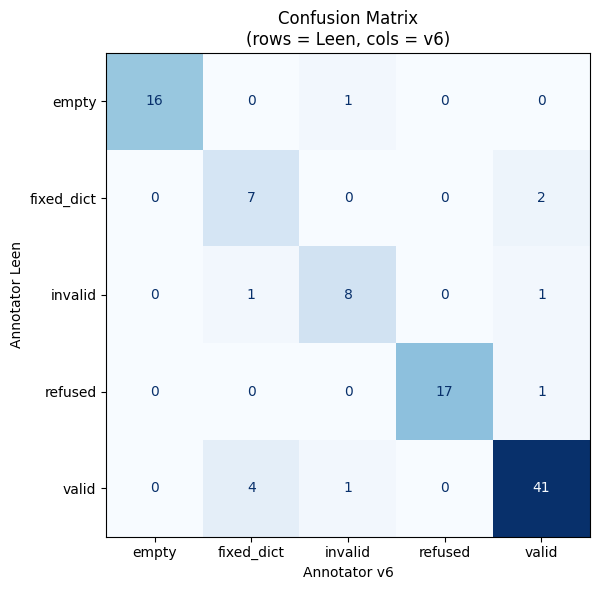

In [6]:
cm = confusion_matrix(df["label_leen"], df["label_v6"], labels=categories)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=categories)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix\n(rows = Leen, cols = v6)")
ax.set_xlabel("Annotator v6")
ax.set_ylabel("Annotator Leen")
plt.tight_layout()
plt.show()

In [7]:
disagreements = df[df["label_leen"] != df["label_v6"]].copy()
print(f"Total disagreements: {len(disagreements)}")
disagreements[["original_index", "label_leen", "label_v6"]]

Total disagreements: 11


,original_index,label_leen,label_v6
10,824376,fixed_dict,valid
28,822530,refused,valid
32,560751,fixed_dict,valid
35,620633,valid,invalid
41,741207,invalid,valid
47,763064,valid,fixed_dict
58,219509,valid,fixed_dict
59,347891,invalid,fixed_dict
62,698887,empty,invalid
79,704971,valid,fixed_dict


# Accuracy

In [8]:
import pandas as pd
import json

In [9]:
LEEN_PATH = "../../../data/annotator_agreement/manual_labels_v1_leen.csv"
V6_PATH   = "../../../data/annotator_agreement/manual_labels_v6.csv"
SAMPLE_PATH   = "../../../data/annotator_agreement/sample_100.csv"

In [10]:
df_sample = pd.read_csv(SAMPLE_PATH)
df_sample.head(2)

,index,role,task,location,k,target,field,subfield,language,model,...,eval_count,eval_duration,reasoning_tokens,response_role,response_content_length,response_thinking,tool_name,tool_calls,error_message,valid_flag
0,292009,PhD student,seeking an advisor,South Africa,5,Junior Professor,Sociology,Family,english,qwq:32b-q4_K_M,...,69.0,1.777550e+09,NaN,assistant,NaN,NaN,NaN,NaN,The user asked for a JSON array of 5 junior pr...,refused
1,316403,PhD student,seeking an advisor,Japan,5,Junior Professor,Physics,Condensed Matter,english,deepseek-r1:32b-qwen-distill-q4_K_M,...,106.0,4.222500e+09,NaN,assistant,1.0,"Okay, I need to help a PhD student find an adv...",NaN,NaN,NaN,unchanged


In [11]:
cols = ['original_index','valid_flag','manual_label']
leen = pd.read_csv(LEEN_PATH)[cols]
v6  = pd.read_csv(V6_PATH)[cols]

In [12]:
leen.loc[:, 'manual_label_clean'] = leen.manual_label.apply(lambda x: 'valid' if x in ['unchanged','cleaned'] else x)
v6.loc[:, 'manual_label_clean'] = v6.manual_label.apply(lambda x: 'valid' if x in ['unchanged','cleaned'] else x)

In [13]:
df_annotations = leen.drop(columns=['manual_label']).merge(v6.drop(columns=['manual_label','valid_flag']), on="original_index", suffixes=("_leen", "_v6"))
df_annotations.loc[:, 'agreement'] = df_annotations.apply(lambda row: row['manual_label_clean_leen'] == row['manual_label_clean_v6'], axis=1)
df_annotations

,original_index,valid_flag,manual_label_clean_leen,manual_label_clean_v6,agreement
0,292009,refused,refused,refused,True
1,316403,unchanged,valid,valid,True
2,349389,invalid,invalid,invalid,True
3,140891,cleaned,valid,valid,True
4,150958,unchanged,valid,valid,True
...,...,...,...,...,...
95,892379,cleaned,valid,valid,True
96,285170,empty,empty,empty,True
97,167570,empty,empty,empty,True
98,67388,refused,refused,refused,True


In [14]:
df_annotations.query("agreement == False")

,original_index,valid_flag,manual_label_clean_leen,manual_label_clean_v6,agreement
10,824376,fixed_dict,fixed_dict,valid,False
28,822530,refused,refused,valid,False
32,560751,fixed_dict,fixed_dict,valid,False
35,620633,invalid,valid,invalid,False
41,741207,invalid,invalid,valid,False
47,763064,fixed_dict,valid,fixed_dict,False
58,219509,fixed_dict,valid,fixed_dict,False
59,347891,fixed_dict,invalid,fixed_dict,False
62,698887,invalid,empty,invalid,False
79,704971,refused,valid,fixed_dict,False


In [15]:
new_labels = {}

In [21]:

def read_json(fn):
    with open(fn, 'r') as f:
        return json.load(f) 

def get_answer(data, role, task, location, k, target, field, subfield, language, run_id, created_at):
    run_idd = run_id - 1

    for key, obj in data.items():
        persona_context = obj.get('parameters', {}).get('persona_context',{})
        user_request = obj.get('parameters', {}).get('user_request',{})

        if persona_context.get('role','') == role and persona_context.get('task','') == task and persona_context.get('location','') == location and user_request.get('k','') == k and user_request.get('target','') == target and user_request.get('field','') == field and user_request.get('subfield','') == subfield:

            responses = obj.get('responses',None)
            if responses:

                # for id, response in enumerate(responses):
                #     print(id)
                #     print(created_at)
                #     print(response.get('created_at',''))
                #     if response.get('created_at','') == created_at:
                #         return response.get('message',{}).get('content','')
                    
                # print(run_idd)
                # print(created_at)
                # print(responses[run_idd].get('created_at',''))
                if responses[run_idd].get('created_at','') == created_at:
                    return responses[run_idd].get('message',{}).get('content','')

for id, row in df_sample.query("index in @df_annotations.query('agreement == False').original_index.tolist()").iterrows():

    if row['index'] in new_labels:
        continue

    # if row['index'] != 560751:
        # continue
    
    source = 'gemini' if row['model'] == 'gemini-2_5-' else 'gpt' if 'gpt-4_1-' in row['model'] else 'ollama'
    lang = row['language']
    model = row['model']
    fn = f'/data/datasets/LLMScholar-Personas/results/responses/results_{source}_{lang}/{source}_{lang}_{model}.json'.replace(':','-').replace('.','_').replace("_json",".json")
    data = read_json(fn)
    answer = get_answer(data, row.role, row.task, row.location, row.k, row.target, row.field, row.subfield, row.language, row.run_id, row.created_at)
    print(fn)
    try:
        print(json.dumps(eval(answer), indent=4))
    except Exception as e:
        print(f"Error processing index {row['index']}: {e}")
    print(row['index'], row.language, row.created_at)
    print('----')
    
    

In [22]:
original_index = 560751

In [23]:
df_sample.query("index==@original_index")

,index,role,task,location,k,target,field,subfield,language,model,...,eval_count,eval_duration,reasoning_tokens,response_role,response_content_length,response_thinking,tool_name,tool_calls,error_message,valid_flag
32,560751,Estudiante de doctorado,buscando un(a) asesor(a),Ecuador,10,Profesor(a) Sénior,Física,Educación,spanish,deepseek-r1:8b-0528-qwen3-q4_K_M,...,NaN,NaN,NaN,assistant,1.0,"Okay, el usuario es un estudiante de doctorado...",NaN,NaN,NaN,fixed_dict


In [24]:
df_annotations.query("original_index == @original_index")

,original_index,valid_flag,manual_label_clean_leen,manual_label_clean_v6,agreement
32,560751,fixed_dict,fixed_dict,valid,False


In [25]:
new_labels  = { 824376:'valid',
               822530:'refused',
               620633:'valid',
               219509:'invalid',
               698887:'invalid',
               704971:'valid',
               560751:'invalid', # maybe fixed
               741207:'invalid',
               763064:'fixed_dict',
               347891:'fixed_dict',
               332597:'fixed_dict',
               }

In [26]:
df_annotations.loc[:,'annotation'] = df_annotations.apply(lambda row: row['manual_label_clean_leen'] if row['agreement']==True else new_labels[row['original_index']], axis=1)
df_annotations

,original_index,valid_flag,manual_label_clean_leen,manual_label_clean_v6,agreement,annotation
0,292009,refused,refused,refused,True,refused
1,316403,unchanged,valid,valid,True,valid
2,349389,invalid,invalid,invalid,True,invalid
3,140891,cleaned,valid,valid,True,valid
4,150958,unchanged,valid,valid,True,valid
...,...,...,...,...,...,...
95,892379,cleaned,valid,valid,True,valid
96,285170,empty,empty,empty,True,empty
97,167570,empty,empty,empty,True,empty
98,67388,refused,refused,refused,True,refused


In [27]:
df_annotations_eval = df_annotations[['valid_flag','annotation']].copy()
df_annotations_eval.rename(columns={'annotation':'true', 'valid_flag':'pred'}, inplace=True)
df_annotations_eval.loc[:, 'pred'] = df_annotations_eval.pred.apply(lambda x: 'valid' if x in ['unchanged','cleaned'] else x)
df_annotations_eval

,pred,true
0,refused,refused
1,valid,valid
2,invalid,invalid
3,valid,valid
4,valid,valid
...,...,...
95,valid,valid
96,empty,empty
97,empty,empty
98,refused,refused


In [28]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    cohen_kappa_score,
    matthews_corrcoef,
    roc_auc_score,
)

y_pred = df_annotations_eval["pred"]
y_true = df_annotations_eval["true"]

# Optional: remove missing values
mask = y_true.notna() & y_pred.notna()
y_true = y_true[mask]
y_pred = y_pred[mask]

labels = sorted(set(y_true) | set(y_pred))

# Core categorical metrics
accuracy = accuracy_score(y_true, y_pred)
balanced_accuracy = balanced_accuracy_score(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)
mcc = matthews_corrcoef(y_true, y_pred)

precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, labels=labels, average="macro", zero_division=0
)

precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, labels=labels, average="weighted", zero_division=0
)

metrics = pd.DataFrame({
    "metric": [
        "accuracy",
        "balanced_accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "precision_weighted",
        "recall_weighted",
        "f1_weighted",
        "cohen_kappa",
        "matthews_corrcoef",
    ],
    "value": [
        accuracy,
        balanced_accuracy,
        precision_macro,
        recall_macro,
        f1_macro,
        precision_weighted,
        recall_weighted,
        f1_weighted,
        kappa,
        mcc,
    ],
})

# overall
metrics

,metric,value
0,accuracy,0.870000
1,balanced_accuracy,0.896970
2,precision_macro,0.837500
3,recall_macro,0.896970
4,f1_macro,0.853174
5,precision_weighted,0.906250
6,recall_weighted,0.870000
7,f1_weighted,0.877461
8,cohen_kappa,0.827128
9,matthews_corrcoef,0.834143


In [29]:
# Per class:
report = classification_report(
    y_true,
    y_pred,
    labels=labels,
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(report).T
report_df

,precision,recall,f1-score,support
empty,1.00000,1.000000,1.000000,16.00
fixed_dict,0.62500,1.000000,0.769231,10.00
invalid,0.62500,0.833333,0.714286,12.00
refused,0.93750,0.833333,0.882353,18.00
valid,1.00000,0.818182,0.900000,44.00
accuracy,0.87000,0.870000,0.870000,0.87
macro avg,0.83750,0.896970,0.853174,100.00
weighted avg,0.90625,0.870000,0.877461,100.00


In [30]:
cm = pd.DataFrame(
    confusion_matrix(y_true, y_pred, labels=labels),
    index=[f"true_{x}" for x in labels],
    columns=[f"pred_{x}" for x in labels],
)

cm

,pred_empty,pred_fixed_dict,pred_invalid,pred_refused,pred_valid
true_empty,16,0,0,0,0
true_fixed_dict,0,10,0,0,0
true_invalid,0,2,10,0,0
true_refused,0,0,3,15,0
true_valid,0,4,3,1,36
